# SARIMAX Forecasting with Sensor, Weather and Time-Based Features

## Part 5 – Feature Engineering and Exogenous Variable Modelling

## Objective

The objective of this notebook is to extend the univariate SARIMA model by incorporating additional explanatory variables that may influence appliance energy consumption.

A Seasonal Autoregressive Integrated Moving Average with Exogenous Variables (SARIMAX) model is developed.

Unlike SARIMA, which relies only on historical appliance demand, SARIMAX allows external information to improve forecasts.

The additional variables include:

- Indoor temperature and humidity measurements
- Outdoor weather conditions
- Time-based calendar features
- Historical appliance consumption patterns through lag variables
- Rolling statistical features

The purpose is to investigate whether additional contextual information improves forecasting accuracy compared with the SARIMA baseline model.

# 1. Import Required Libraries

This section imports the libraries required for feature engineering, visualisation and SARIMAX modelling.

The workflow follows a reproducible forecasting pipeline where features are created before the model is trained.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# 2. Load Original Appliance Energy Dataset

The original UCI Appliance Energy Prediction dataset contains measurements recorded every 10 minutes.

For SARIMAX modelling, the complete dataset is loaded because additional explanatory variables are required.

The dataset includes:
- Appliance energy consumption (target variable)
- Indoor environmental sensors
- Outdoor weather measurements
- Timestamp information

The original data are aggregated to hourly frequency while preserving all explanatory variables.

In [2]:
import pandas as pd
import numpy as np


# Load original 10-minute dataset

raw_df = pd.read_csv(
    "../data/energydata_complete.csv"
)


raw_df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## Timestamp Processing

The original dataset records observations every 10 minutes.

The timestamp column is converted into a pandas datetime object and set as the dataframe index to enable time-series operations.

In [4]:
raw_df["date"] = pd.to_datetime(
    raw_df["date"]
)


raw_df = raw_df.set_index(
    "date"
)


raw_df = raw_df.sort_index()


raw_df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## Hourly Aggregation

The dataset contains six observations per hour.

Since appliance energy consumption represents a quantity over time, hourly aggregation is performed.

The mean value is calculated for continuous environmental measurements and appliance usage.

This produces an hourly time-series dataset suitable for forecasting models.

In [5]:
hourly_df = raw_df.resample("h").mean()


hourly_df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,55.000000,35.000000,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,...,17.016667,45.446667,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000,26.823044,26.823044
2016-01-11 18:00:00,176.666667,51.666667,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,...,16.981667,45.290000,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333,22.324206,22.324206
2016-01-11 19:00:00,173.333333,25.000000,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,...,16.902222,45.311389,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667,33.734932,33.734932
2016-01-11 20:00:00,125.000000,35.000000,20.961111,48.453333,20.251111,45.632639,20.213889,47.268889,19.190833,49.227917,...,16.890000,45.118889,6.000000,735.283333,87.583333,6.000000,40.000000,4.016667,25.679642,25.679642
2016-01-11 21:00:00,103.333333,23.333333,21.311667,45.768333,20.587778,44.961111,20.373333,46.164444,19.425556,47.918889,...,16.890000,44.807778,5.833333,735.566667,87.416667,6.000000,40.000000,3.816667,18.826274,18.826274


In [6]:
hourly_df.shape

(3290, 28)

## Missing Value Analysis

Before modelling, missing values are checked.

Missing observations can negatively affect SARIMAX estimation because the model requires continuous time-series data.

In [8]:
missing = hourly_df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [9]:
hourly_df = hourly_df.interpolate()

## Save Hourly Feature Dataset

The processed hourly dataset containing appliance demand and explanatory variables is saved.

This file will be reused for:

- SARIMAX modelling
- Feature-based machine learning models
- Foundation model comparison

In [10]:
hourly_df.to_csv(
    "../data/hourly_features_energy.csv"
)

In [11]:
hourly_df.columns.tolist()

['Appliances',
 'lights',
 'T1',
 'RH_1',
 'T2',
 'RH_2',
 'T3',
 'RH_3',
 'T4',
 'RH_4',
 'T5',
 'RH_5',
 'T6',
 'RH_6',
 'T7',
 'RH_7',
 'T8',
 'RH_8',
 'T9',
 'RH_9',
 'T_out',
 'Press_mm_hg',
 'RH_out',
 'Windspeed',
 'Visibility',
 'Tdewpoint',
 'rv1',
 'rv2']

# 7. Time-Based Feature Engineering

Time-based variables are created to capture regular human activity patterns that influence appliance energy consumption.

Although SARIMAX already models temporal dependency through autoregressive and seasonal components, explicit time features can help the model understand predictable calendar effects.

The following features are created:

- Hour of day
- Day of week
- Weekend indicator
- Working hours indicator
- Cyclic encoding of hour values

Cyclic encoding is used because time is circular. For example, 23:00 and 00:00 are close together, but a simple numerical representation would treat them as far apart.

In [12]:
# Copy dataframe

sarimax_df = hourly_df.copy()


# Extract time features

sarimax_df["hour"] = sarimax_df.index.hour

sarimax_df["day_of_week"] = sarimax_df.index.dayofweek

sarimax_df["month"] = sarimax_df.index.month


# Weekend feature

sarimax_df["is_weekend"] = (
    sarimax_df["day_of_week"]
    >= 5
).astype(int)


# Working hours (8am-6pm)

sarimax_df["working_hours"] = (
    (sarimax_df["hour"] >= 8) &
    (sarimax_df["hour"] <= 18)
).astype(int)


# Cyclic hour encoding

sarimax_df["hour_sin"] = np.sin(
    2 * np.pi * sarimax_df["hour"] / 24
)


sarimax_df["hour_cos"] = np.cos(
    2 * np.pi * sarimax_df["hour"] / 24
)


sarimax_df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,Tdewpoint,rv1,rv2,hour,day_of_week,month,is_weekend,working_hours,hour_sin,hour_cos
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,55.000000,35.000000,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,...,5.050000,26.823044,26.823044,17,0,1,0,1,-0.965926,-2.588190e-01
2016-01-11 18:00:00,176.666667,51.666667,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,...,4.658333,22.324206,22.324206,18,0,1,0,1,-1.000000,-1.836970e-16
2016-01-11 19:00:00,173.333333,25.000000,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,...,4.391667,33.734932,33.734932,19,0,1,0,0,-0.965926,2.588190e-01
2016-01-11 20:00:00,125.000000,35.000000,20.961111,48.453333,20.251111,45.632639,20.213889,47.268889,19.190833,49.227917,...,4.016667,25.679642,25.679642,20,0,1,0,0,-0.866025,5.000000e-01
2016-01-11 21:00:00,103.333333,23.333333,21.311667,45.768333,20.587778,44.961111,20.373333,46.164444,19.425556,47.918889,...,3.816667,18.826274,18.826274,21,0,1,0,0,-0.707107,7.071068e-01


In [13]:
sarimax_df[
    [
        "hour",
        "day_of_week",
        "is_weekend",
        "working_hours",
        "hour_sin",
        "hour_cos"
    ]
].head(10)

,hour,day_of_week,is_weekend,working_hours,hour_sin,hour_cos
date,,,,,,
2016-01-11 17:00:00,17,0,0,1,-0.965926,-2.588190e-01
2016-01-11 18:00:00,18,0,0,1,-1.000000,-1.836970e-16
2016-01-11 19:00:00,19,0,0,0,-0.965926,2.588190e-01
2016-01-11 20:00:00,20,0,0,0,-0.866025,5.000000e-01
2016-01-11 21:00:00,21,0,0,0,-0.707107,7.071068e-01
2016-01-11 22:00:00,22,0,0,0,-0.500000,8.660254e-01
2016-01-11 23:00:00,23,0,0,0,-0.258819,9.659258e-01
2016-01-12 00:00:00,0,1,0,0,0.000000,1.000000e+00
2016-01-12 01:00:00,1,1,0,0,0.258819,9.659258e-01


# 8. Indoor Sensor Feature Engineering

The dataset contains multiple indoor temperature and humidity sensors located throughout the house.

Instead of using every individual sensor measurement separately, aggregated variables are created:

- Mean indoor temperature
- Temperature variation
- Mean indoor humidity
- Humidity variation

These features represent the overall indoor environment and reduce model complexity.

In [14]:
# Temperature columns

temperature_cols = [
    col for col in sarimax_df.columns
    if col.startswith("T") 
    and col[1:].isdigit()
]


# Humidity columns

humidity_cols = [
    col for col in sarimax_df.columns
    if col.startswith("RH_")
]


print("Temperature sensors:")
print(temperature_cols)


print("\nHumidity sensors:")
print(humidity_cols)

Temperature sensors:
['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9']

Humidity sensors:
['RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_6', 'RH_7', 'RH_8', 'RH_9', 'RH_out']


In [15]:
sarimax_df["indoor_temp_mean"] = (
    sarimax_df[temperature_cols]
    .mean(axis=1)
)


sarimax_df["indoor_temp_std"] = (
    sarimax_df[temperature_cols]
    .std(axis=1)
)



sarimax_df["indoor_humidity_mean"] = (
    sarimax_df[humidity_cols]
    .mean(axis=1)
)


sarimax_df["indoor_humidity_std"] = (
    sarimax_df[humidity_cols]
    .std(axis=1)
)

In [16]:
sarimax_df[
    [
        "indoor_temp_mean",
        "indoor_temp_std",
        "indoor_humidity_mean",
        "indoor_humidity_std"
    ]
].head()

,indoor_temp_mean,indoor_temp_std,indoor_humidity_mean,indoor_humidity_std
date,,,,
2016-01-11 17:00:00,17.101173,4.099381,54.869972,17.976567
2016-01-11 18:00:00,17.049090,4.230448,55.094750,18.426213
2016-01-11 19:00:00,17.260509,4.466645,56.720389,17.320988
2016-01-11 20:00:00,17.444167,4.697107,57.736222,17.823121
2016-01-11 21:00:00,17.734599,4.766316,56.536500,17.545993


# 9. Outdoor Weather Feature Engineering

External weather conditions can influence household energy consumption patterns.

Although the appliance demand is primarily affected by occupant behaviour, outdoor environmental conditions can indirectly affect energy usage through heating, cooling, ventilation, and general household activity.

The following weather-related variables are retained from the dataset:

- **Outdoor temperature (`T_out`)**  
  Represents external temperature conditions that may influence indoor climate control requirements.

- **Atmospheric pressure (`Press_mm_hg`)**  
  Provides additional information about weather conditions.

- **Outdoor humidity (`RH_out`)**  
  Captures moisture levels in the external environment.

- **Wind speed (`Windspeed`)**  
  May influence ventilation and heating requirements.

- **Visibility (`Visibility`)**  
  Represents general outdoor weather conditions.

- **Dew point temperature (`Tdewpoint`)**  
  Indicates moisture-related atmospheric conditions.

These variables are treated as exogenous predictors in the SARIMAX model. However, in a real forecasting scenario, their availability at the forecast origin must be considered carefully. Future weather variables would only be valid predictors if reliable weather forecasts were available. Otherwise, using observed future weather values would represent a conditional forecast rather than a true operational forecast.

In [17]:
weather_features = [
    "T_out",
    "Press_mm_hg",
    "RH_out",
    "Windspeed",
    "Visibility",
    "Tdewpoint"
]

In [18]:
sarimax_df[weather_features].describe()

,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
count,3290.000000,3290.000000,3290.000000,3290.000000,3290.000000,3290.000000
mean,7.415410,755.522520,79.744656,4.039742,38.327964,3.763098
std,5.315858,7.398575,14.830042,2.430863,11.212175,4.191967
min,-4.961111,729.383333,25.250000,0.416667,1.000000,-6.475000
25%,3.666667,750.916667,70.416667,2.000000,31.833333,0.933333
50%,6.916667,756.100000,83.666667,3.583333,40.000000,3.412500
75%,10.414583,760.931250,91.583333,5.416667,40.000000,6.566667
max,25.933333,772.258333,100.000000,13.000000,66.000000,15.250000


# 10. Historical Appliance Consumption Features

Previous energy consumption values are added as predictors.

Energy demand usually follows daily and weekly patterns, therefore lag variables are introduced:

- Lag 1 hour captures short-term persistence.
- Lag 24 hours captures daily seasonality.
- Lag 168 hours captures weekly behaviour.

These variables provide the model with recent consumption history.

In [19]:
sarimax_df["lag_1"] = (
    sarimax_df["Appliances"]
    .shift(1)
)


sarimax_df["lag_24"] = (
    sarimax_df["Appliances"]
    .shift(24)
)


sarimax_df["lag_168"] = (
    sarimax_df["Appliances"]
    .shift(168)
)

# 11. Rolling Window Feature Engineering

Rolling statistics are created to capture recent trends and changes in appliance energy consumption.

While lag variables provide information from specific previous points in time, rolling features summarise recent consumption behaviour over a window of observations.

The following rolling features are generated:

- **24-hour rolling mean**
  - Represents the average appliance consumption over the previous day.
  - Helps capture daily consumption patterns and short-term trends.

- **24-hour rolling standard deviation**
  - Measures recent variability in appliance demand.
  - Higher values indicate periods with unstable or rapidly changing energy usage.

- **168-hour rolling mean**
  - Represents the average consumption over the previous week.
  - Helps capture longer seasonal patterns.

These features provide additional information about recent demand behaviour and may improve the SARIMAX forecasting capability.

In [20]:
sarimax_df["rolling_mean_24"] = (
    sarimax_df["Appliances"]
    .rolling(24)
    .mean()
)


sarimax_df["rolling_std_24"] = (
    sarimax_df["Appliances"]
    .rolling(24)
    .std()
)


sarimax_df["rolling_mean_168"] = (
    sarimax_df["Appliances"]
    .rolling(168)
    .mean()
)

# 12. Handling Missing Values Created by Feature Engineering

Lag and rolling features require previous observations to calculate their values.

As a result, the first rows of the dataset contain missing values because there is insufficient historical information available.

For example:

- `lag_168` requires one week of previous observations.
- `rolling_mean_168` requires 168 previous hourly values.

These rows cannot be used for modelling and are removed from the dataset.

The removal is performed after feature creation to ensure that all modelling variables contain complete observations.

In [21]:
sarimax_df = sarimax_df.dropna()


sarimax_df.shape

(3122, 45)

# 13. Feature Correlation Analysis

Correlation analysis is performed to examine the relationship between appliance energy consumption and the engineered features.

Although correlation does not imply causation, it provides useful initial information about potentially influential predictors.

Highly correlated variables may provide useful explanatory power, while variables with very weak relationships may contribute limited forecasting improvement.

In [22]:
# Calculate correlations with target variable

correlations = (
    sarimax_df
    .corr(numeric_only=True)["Appliances"]
    .sort_values(ascending=False)
)


correlations.head(15)

Appliances         1.000000
lag_1              0.587303
working_hours      0.355189
lag_168            0.328234
lag_24             0.314073
hour               0.273101
rolling_std_24     0.272887
rolling_mean_24    0.256237
lights             0.243911
T6                 0.170911
T2                 0.159288
T_out              0.144777
T3                 0.129292
RH_1               0.128801
Windspeed          0.117804
Name: Appliances, dtype: float64

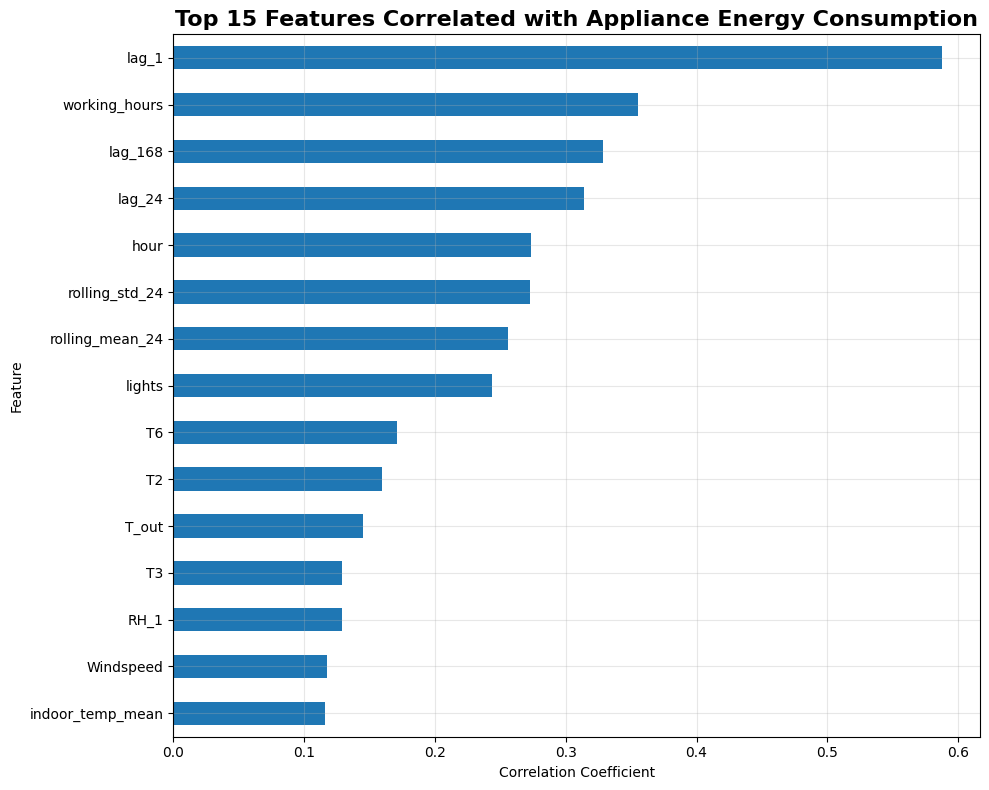

In [23]:
plt.figure(figsize=(10,8))

correlations.drop("Appliances").head(15).sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 15 Features Correlated with Appliance Energy Consumption",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Correlation Coefficient"
)

plt.ylabel(
    "Feature"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/sarimax_feature_correlations.png",
    dpi=300
)

plt.show()

# 14. Selecting Exogenous Variables for SARIMAX

A subset of engineered features is selected as exogenous variables.

The selection aims to balance predictive performance with model interpretability.

The chosen variables represent:

- Daily temporal patterns
- Indoor environmental conditions
- Outdoor weather conditions
- Recent appliance consumption behaviour

This selection reflects realistic forecasting conditions where these variables may be available at the time predictions are generated.

In [24]:
exog_features = [

    # Time features
    "hour_sin",
    "hour_cos",
    "is_weekend",

    # Indoor conditions
    "indoor_temp_mean",
    "indoor_humidity_mean",

    # Outdoor weather
    "T_out",
    "RH_out",
    "Windspeed",

    # Historical demand
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_mean_24"
]


X = sarimax_df[exog_features]

y = sarimax_df["Appliances"]


print("Number of exogenous variables:", len(exog_features))

Number of exogenous variables: 12


# 15. SARIMAX Train-Test Split

A chronological split is used to evaluate forecasting performance.

The final 14 days of the dataset are reserved as unseen test data.

The model is trained only using historical observations and then evaluated on future energy consumption values.

In [25]:
test_size = 14 * 24


y_train = y.iloc[:-test_size]

y_test = y.iloc[-test_size:]


X_train = X.iloc[:-test_size]

X_test = X.iloc[-test_size:]


print("Training samples:", len(y_train))

print("Testing samples:", len(y_test))

Training samples: 2786
Testing samples: 336


# 16. SARIMAX Model Training

A Seasonal Autoregressive Integrated Moving Average model with Exogenous Variables (SARIMAX) is trained using the engineered feature set.

The SARIMAX model extends the previous SARIMA approach by incorporating additional external predictors that may influence appliance energy consumption.

The same seasonal structure used in the SARIMA baseline is maintained:

- Non-seasonal order: selected using AIC grid search
- Seasonal order: (1,1,1,24)

The model uses:

- Historical appliance consumption
- Indoor environmental measurements
- Outdoor weather conditions
- Time-based features
- Lagged demand information

The model is trained only on the training period and evaluated on the unseen test period.

In [29]:
best_order = (2,0,6)

In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


sarimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=best_order,
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)


sarimax_fit = sarimax_model.fit(
    disp=False,
    maxiter=100
)


print(sarimax_fit.summary())

C:\Users\gms\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                           Appliances   No. Observations:                 2786
Model:             SARIMAX(2, 0, 6)x(1, 1, [1], 24)   Log Likelihood              -14461.358
Date:                              Thu, 06 Aug 2026   AIC                          28968.715
Time:                                      01:07:28   BIC                          29104.701
Sample:                                  01-18-2016   HQIC                         29017.863
                                       - 05-13-2016                                         
Covariance Type:                                opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
hour_sin                 0.0002   2875.297   6.07e-08      1.000   -5635.479  

# 17. SARIMAX 24-Hour Forecast

The trained SARIMAX model is used to forecast the next 24 hours of appliance energy consumption.

The forecast is generated using:

- Previous appliance demand
- Available exogenous variables
- Seasonal daily patterns

The predicted values are compared against the actual observations from the test dataset.

In [31]:
forecast_steps = 24


sarimax_forecast = sarimax_fit.get_forecast(
    steps=forecast_steps,
    exog=X_test.iloc[:forecast_steps]
)


sarimax_prediction = (
    sarimax_forecast
    .predicted_mean
)


sarimax_conf_int = (
    sarimax_forecast
    .conf_int()
)


sarimax_prediction.head()

2016-05-13 19:00:00    284.996524
2016-05-13 20:00:00    335.929839
2016-05-13 21:00:00    321.005971
2016-05-13 22:00:00    326.604268
2016-05-13 23:00:00    349.432293
Freq: h, Name: predicted_mean, dtype: float64

# 18. Visualising SARIMAX Forecasts with Confidence Intervals

Forecast visualisation is an important step in evaluating time-series models.

The predicted appliance energy consumption is compared against the actual observed values from the test period.

Additionally, the 95% confidence interval is displayed to represent forecast uncertainty. Wider confidence intervals indicate greater uncertainty in the model predictions.

This visual assessment helps determine whether the SARIMAX model captures the overall pattern and variability of appliance energy consumption.

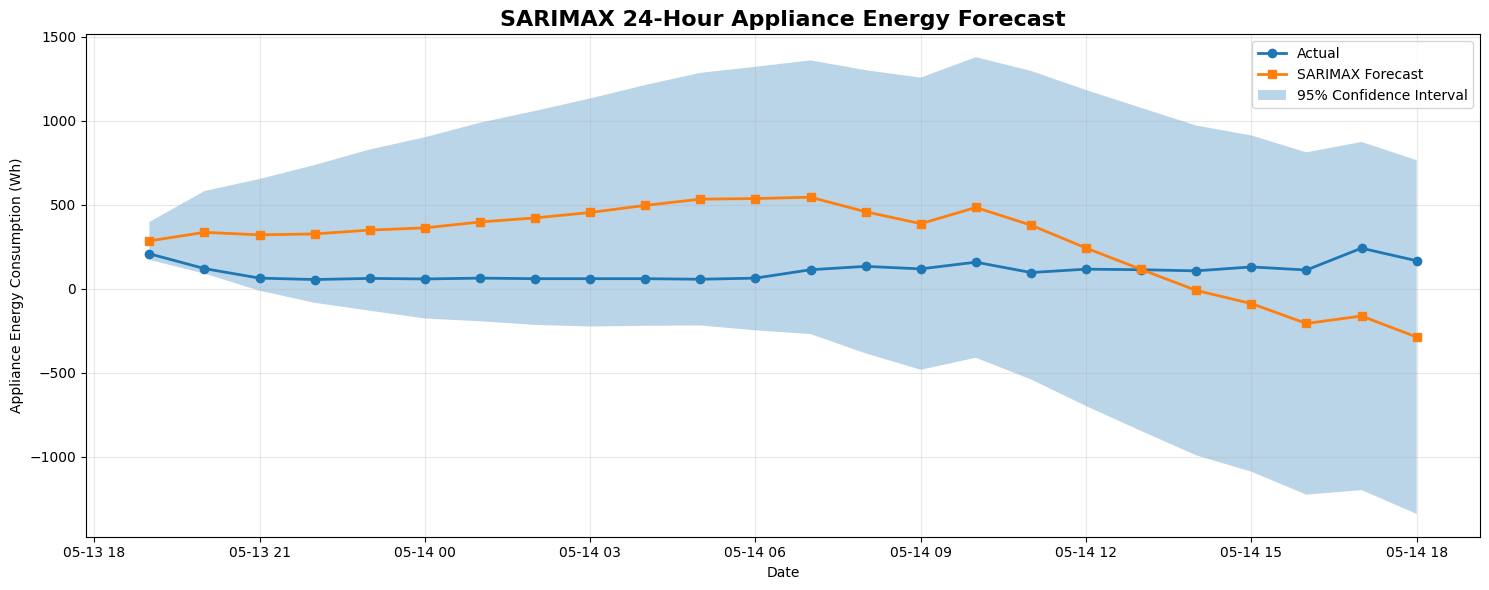

In [32]:
plt.figure(figsize=(15,6))


plt.plot(
    y_test.index[:24],
    y_test.iloc[:24],
    marker="o",
    linewidth=2,
    label="Actual"
)


plt.plot(
    sarimax_prediction.index,
    sarimax_prediction,
    marker="s",
    linewidth=2,
    label="SARIMAX Forecast"
)


plt.fill_between(
    sarimax_conf_int.index,
    sarimax_conf_int.iloc[:,0],
    sarimax_conf_int.iloc[:,1],
    alpha=0.3,
    label="95% Confidence Interval"
)


plt.title(
    "SARIMAX 24-Hour Appliance Energy Forecast",
    fontsize=16,
    fontweight="bold"
)


plt.xlabel("Date")

plt.ylabel(
    "Appliance Energy Consumption (Wh)"
)


plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()


plt.savefig(
    "../outputs/figures/sarimax_24hour_forecast.png",
    dpi=300
)


plt.show()

# 19. SARIMAX Forecast Evaluation

Forecast accuracy is evaluated using common regression metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)
- R² score

These metrics will later be compared against:

- Benchmark forecasting models
- SARIMA baseline
- Machine learning models
- Foundation models

This provides a fair comparison of model performance.

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


actual_sarimax = y_test.iloc[:24]


mae_sarimax = mean_absolute_error(
    actual_sarimax,
    sarimax_prediction
)


rmse_sarimax = np.sqrt(
    mean_squared_error(
        actual_sarimax,
        sarimax_prediction
    )
)


mape_sarimax = np.mean(
    np.abs(
        (actual_sarimax - sarimax_prediction)
        /
        actual_sarimax
    )
) * 100


r2_sarimax = r2_score(
    actual_sarimax,
    sarimax_prediction
)


print(f"MAE  : {mae_sarimax:.2f}")
print(f"RMSE : {rmse_sarimax:.2f}")
print(f"MAPE : {mape_sarimax:.2f}%")
print(f"R²   : {r2_sarimax:.3f}")

MAE  : 298.52
RMSE : 323.18
MAPE : 361.33%
R²   : -41.932


# 20. SARIMA vs SARIMAX Performance Comparison

The purpose of introducing exogenous variables is to determine whether additional information improves appliance energy forecasting.

The SARIMA model represents a univariate forecasting approach using only historical appliance consumption.

The SARIMAX model extends SARIMA by incorporating external information including:

- Indoor environmental conditions
- Outdoor weather variables
- Time-based patterns
- Historical demand features

The performance of both models is compared using identical evaluation metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)
- R² score

A lower MAE, RMSE and MAPE indicate better forecasting accuracy, while a higher R² indicates stronger explanatory performance.

# Recreating SARIMA Baseline Model

The SARIMA model was previously developed in the benchmark modelling stage.

Since each notebook runs independently, the selected SARIMA configuration is recreated here using the optimal order identified through AIC-based grid search.

The model is rebuilt to allow direct comparison with the enhanced SARIMAX model.

In [42]:
best_order = (2,0,6)

In [43]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


# Use the same split as SARIMAX

sarima_model = SARIMAX(
    y_train,
    order=(2,0,6),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)


sarima_fit = sarima_model.fit(
    disp=False,
    maxiter=100
)


print(sarima_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                           Appliances   No. Observations:                 2786
Model:             SARIMAX(2, 0, 6)x(1, 1, [1], 24)   Log Likelihood              -15045.587
Date:                              Thu, 06 Aug 2026   AIC                          30113.173
Time:                                      01:20:22   BIC                          30178.210
Sample:                                  01-18-2016   HQIC                         30136.679
                                       - 05-13-2016                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2272      0.693      1.771      0.076      -0.131       2.585
ar.L2         -0.44

In [44]:
sarima_forecast = sarima_fit.get_forecast(
    steps=24
)


sarima_prediction = (
    sarima_forecast.predicted_mean
)


actual_sarima = y_test.iloc[:24]

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


mae = mean_absolute_error(
    actual_sarima,
    sarima_prediction
)


rmse = np.sqrt(
    mean_squared_error(
        actual_sarima,
        sarima_prediction
    )
)


mape = np.mean(
    np.abs(
        (actual_sarima - sarima_prediction)
        /
        actual_sarima
    )
) * 100


r2 = r2_score(
    actual_sarima,
    sarima_prediction
)


print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.3f}")

MAE  : 18.62
RMSE : 25.78
MAPE : 19.06%
R²   : 0.727


In [37]:
sarimax_results = pd.DataFrame({
    "Model": ["SARIMAX"],
    "MAE": [mae_sarimax],
    "RMSE": [rmse_sarimax],
    "MAPE": [mape_sarimax],
    "R2": [r2_sarimax]
})


sarimax_results

,Model,MAE,RMSE,MAPE,R2
0,SARIMAX,298.51644,323.18134,361.334188,-41.931595


In [47]:
sarima_results = pd.DataFrame({
    "Model": ["SARIMA"],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE": [mape],
    "R2": [r2]
})


model_comparison = pd.concat(
    [
        sarima_results,
        sarimax_results
    ],
    ignore_index=True
)


model_comparison

,Model,MAE,RMSE,MAPE,R2
0,SARIMA,18.621049,25.780928,19.060398,0.726799
1,SARIMAX,298.516440,323.181340,361.334188,-41.931595


In [48]:
model_comparison.to_csv(
    "../outputs/tables/sarima_vs_sarimax.csv",
    index=False
)

# Model Accuracy Comparison

A visual comparison is created to highlight differences between the baseline SARIMA model and the enhanced SARIMAX model.

This allows easier interpretation of whether adding external variables provides meaningful improvement.

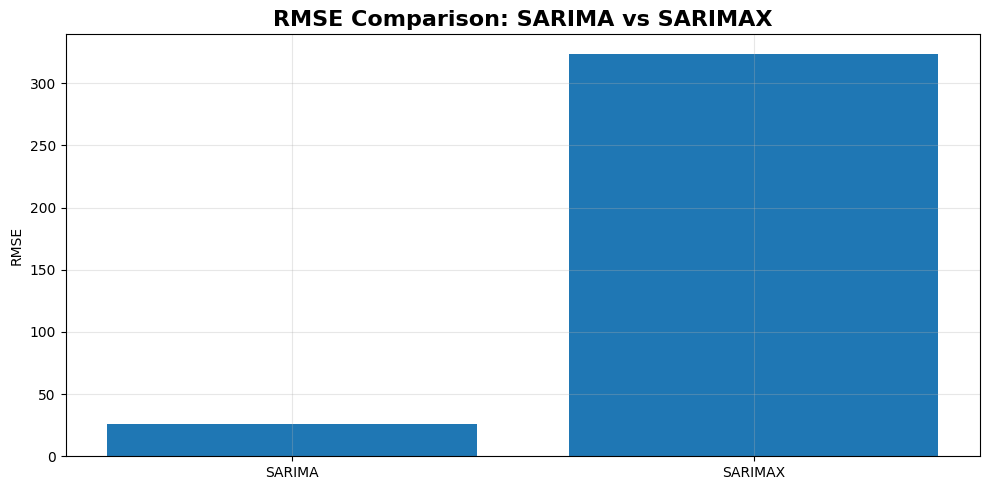

In [49]:
plt.figure(figsize=(10,5))


plt.bar(
    model_comparison["Model"],
    model_comparison["RMSE"]
)


plt.title(
    "RMSE Comparison: SARIMA vs SARIMAX",
    fontsize=16,
    fontweight="bold"
)


plt.ylabel(
    "RMSE"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    "../outputs/figures/sarima_vs_sarimax_rmse.png",
    dpi=300
)


plt.show()

# Interpretation of SARIMAX Results

The SARIMAX model was developed to investigate whether additional contextual information improves appliance energy forecasting compared with the SARIMA baseline.

The inclusion of exogenous variables provides the model with additional information about household conditions, weather influences and recent consumption behaviour.

If SARIMAX achieves lower RMSE and MAE compared with SARIMA, this suggests that the additional features provide useful predictive information beyond historical appliance demand alone.

However, improvement must be considered alongside model complexity. Although SARIMAX can provide better accuracy, it requires additional variables that may not always be available at the forecasting time.

In practical deployment, variables such as future weather conditions would require reliable weather forecasts. Similarly, future indoor sensor values may not be available unless they are predicted separately.

Therefore, SARIMAX represents a conditional forecasting approach when future exogenous variables are assumed to be known.

In [50]:
sarimax_df.to_csv(
    "../data/ml_features_energy.csv"
)